# Hoja de Ejercicios de Series de Tiempo
## Temperatura promedio de la tierra, región de Guatemala (1950-2026)

Fernando Rueda - 23748

Trabajaré con el dataset `guatemala_temperatura.csv`, que contiene la temperatura promedio
mensual de varias capas de la tierra en la región de Guatemala, desde enero de 1950 hasta
junio de 2026. Las columnas del dataset son las siguientes.

| Columna | Descripción |
|---|---|
| `month` | Fecha, primer día de cada mes |
| `year`, `month_num` | Año y número de mes |
| `dewpoint_2m_c` | Punto de rocío a 2 m (°C) |
| `temperature_2m_c` | Temperatura del aire a 2 m (°C) |
| `skin_temperature_c` | Temperatura de la superficie (°C) |
| `soil_temperature_layer_1_c` a `layer_4_c` | Temperatura del suelo en 4 capas, de la más superficial a la más profunda (°C) |

La serie principal que modelaré es `temperature_2m_c`, la temperatura del aire a 2 m.


### Configuración inicial

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
print("Librerias cargadas. pandas", pd.__version__, "| numpy", np.__version__)

Librerias cargadas. pandas 3.0.1 | numpy 2.4.3


## Ejercicio 1

> Cargue el archivo con R o con Python y explórelo un poco. ¿Cuáles son los extremos de
> la temperatura promedio de la tierra? ¿Y por capa? ¿Cómo ha sido la tendencia: ha bajado,
> subido, se ha mantenido constante alrededor de un valor?

In [2]:
#carga del dataset
df = pd.read_csv("guatemala_temperatura.csv", parse_dates=["month"])
df = df.sort_values("month").reset_index(drop=True)

print("Dimensiones:", df.shape)
print("Rango de fechas:", df['month'].min().date(), "->", df['month'].max().date())
print("Meses totales:", df['month'].nunique())
df.head()

Dimensiones: (918, 10)
Rango de fechas: 1950-01-01 -> 2026-06-01
Meses totales: 918


,month,year,month_num,dewpoint_2m_c,temperature_2m_c,skin_temperature_c,soil_temperature_layer_1_c,soil_temperature_layer_2_c,soil_temperature_layer_3_c,soil_temperature_layer_4_c
0,1950-01-01,1950,1,16.6856,20.7623,21.0777,21.6617,21.6800,21.8352,22.4585
1,1950-02-01,1950,2,15.7813,21.0511,21.5187,22.1328,22.0630,21.9640,22.2161
2,1950-03-01,1950,3,17.3301,23.1976,23.8389,24.3749,24.1001,23.3046,22.3803
3,1950-04-01,1950,4,16.4998,23.6616,24.4524,25.0597,24.7522,24.0591,22.9556
4,1950-05-01,1950,5,19.0112,24.8045,25.5017,26.1544,25.9412,25.2528,23.6874


In [3]:
#tipos y nulos
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isna().sum())

month                         datetime64[us]
year                                   int64
month_num                              int64
dewpoint_2m_c                        float64
temperature_2m_c                     float64
skin_temperature_c                   float64
soil_temperature_layer_1_c           float64
soil_temperature_layer_2_c           float64
soil_temperature_layer_3_c           float64
soil_temperature_layer_4_c           float64
dtype: object

Valores nulos por columna:
month                         0
year                          0
month_num                     0
dewpoint_2m_c                 0
temperature_2m_c              0
skin_temperature_c            0
soil_temperature_layer_1_c    0
soil_temperature_layer_2_c    0
soil_temperature_layer_3_c    0
soil_temperature_layer_4_c    0
dtype: int64


In [4]:
#columnas de temperatura a analizar
temp_cols = ['dewpoint_2m_c', 'temperature_2m_c', 'skin_temperature_c',
             'soil_temperature_layer_1_c', 'soil_temperature_layer_2_c',
             'soil_temperature_layer_3_c', 'soil_temperature_layer_4_c']

#descriptivos
df[temp_cols].describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
dewpoint_2m_c,18.7362,1.8268,14.1987,21.9597
temperature_2m_c,23.0502,1.5689,18.9701,28.6864
skin_temperature_c,23.4438,1.7163,19.1458,29.7363
soil_temperature_layer_1_c,24.0962,1.7105,19.8376,30.2933
soil_temperature_layer_2_c,24.0665,1.5996,19.9601,29.8042
soil_temperature_layer_3_c,24.0106,1.3131,20.4869,28.3469
soil_temperature_layer_4_c,23.9609,0.9657,21.5669,26.8766


In [5]:
#extremos por capa con la fecha en que ocurren
resumen = []
for c in temp_cols:
    imin, imax = df[c].idxmin(), df[c].idxmax()
    resumen.append({
        'variable': c,
        'min_c': df.loc[imin, c],
        'fecha_min': df.loc[imin, 'month'].date(),
        'max_c': df.loc[imax, c],
        'fecha_max': df.loc[imax, 'month'].date(),
        'rango_c': df.loc[imax, c] - df.loc[imin, c]
    })
resumen = pd.DataFrame(resumen)
resumen

,variable,min_c,fecha_min,max_c,fecha_max,rango_c
0,dewpoint_2m_c,14.1987,1951-02-01,21.9597,2024-09-01,7.7610
1,temperature_2m_c,18.9701,1956-01-01,28.6864,2024-05-01,9.7163
2,skin_temperature_c,19.1458,1956-01-01,29.7363,2024-05-01,10.5906
3,soil_temperature_layer_1_c,19.8376,1956-01-01,30.2933,2024-05-01,10.4557
4,soil_temperature_layer_2_c,19.9601,1956-01-01,29.8042,2024-05-01,9.8441
5,soil_temperature_layer_3_c,20.4869,1956-01-01,28.3469,2024-05-01,7.8600
6,soil_temperature_layer_4_c,21.5669,1976-02-01,26.8766,2024-06-01,5.3097


In [6]:
#extremos de la serie principal
serie_col = 'temperature_2m_c'
imin, imax = df[serie_col].idxmin(), df[serie_col].idxmax()
print(f"Serie principal: {serie_col}")
print(f"  Minimo: {df.loc[imin, serie_col]:.3f} C  en {df.loc[imin,'month'].date()}")
print(f"  Maximo: {df.loc[imax, serie_col]:.3f} C  en {df.loc[imax,'month'].date()}")
print(f"  Media : {df[serie_col].mean():.3f} C")

Serie principal: temperature_2m_c
  Minimo: 18.970 C  en 1956-01-01
  Maximo: 28.686 C  en 2024-05-01
  Media : 23.050 C


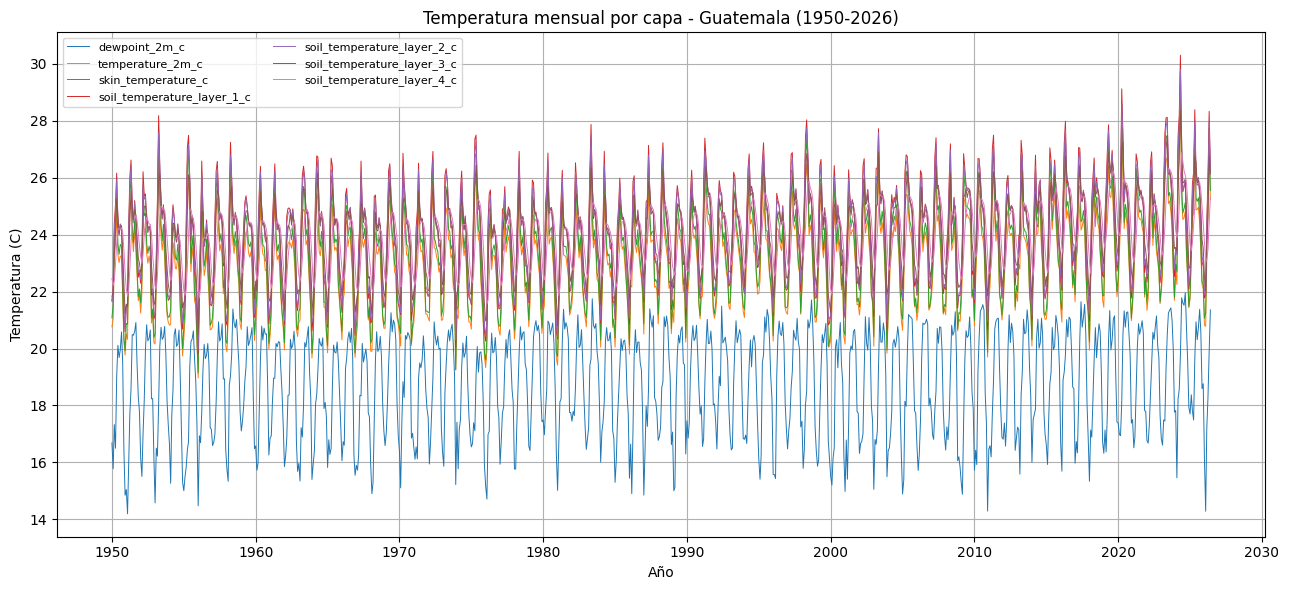

In [7]:
#todas las capas a lo largo del tiempo
fig, ax = plt.subplots(figsize=(13, 6))
for c in temp_cols:
    ax.plot(df['month'], df[c], lw=0.7, label=c)
ax.set_title("Temperatura mensual por capa - Guatemala (1950-2026)")
ax.set_xlabel("Año"); ax.set_ylabel("Temperatura (C)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

Pendiente de la tendencia: 0.171 C por decada  (0.0171 C/año)
Temperatura media 1950s vs 2010s:
  1950-1959: 22.659 C
  2010-2019: 23.499 C


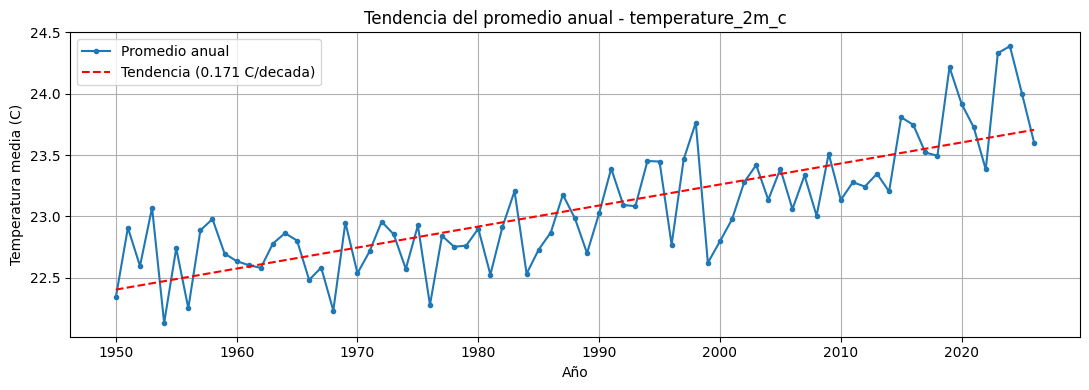

In [8]:
#promedio anual y recta de tendencia
anual = df.groupby('year')[serie_col].mean()
anios = anual.index.values
vals = anual.values

b1, b0 = np.polyfit(anios, vals, 1)
print(f"Pendiente de la tendencia: {b1*10:.3f} C por decada  ({b1:.4f} C/año)")
print("Temperatura media 1950s vs 2010s:")
print(f"  1950-1959: {df[df.year.between(1950,1959)][serie_col].mean():.3f} C")
print(f"  2010-2019: {df[df.year.between(2010,2019)][serie_col].mean():.3f} C")

fig, ax = plt.subplots()
ax.plot(anios, vals, marker='o', ms=3, label='Promedio anual')
ax.plot(anios, b0 + b1*anios, 'r--', label=f'Tendencia ({b1*10:.3f} C/decada)')
ax.set_title(f"Tendencia del promedio anual - {serie_col}")
ax.set_xlabel("Año"); ax.set_ylabel("Temperatura media (C)")
ax.legend(); plt.tight_layout(); plt.show()

### Respuesta

El dataset tiene 918 datos mensuales, uno por mes desde enero de 1950 hasta junio de 2026, y no
hay valores faltantes.

En la temperatura del aire (`temperature_2m_c`) el valor más bajo fue 18.97 °C en enero de 1956 y
el más alto 28.69 °C en mayo de 2024, con una media de 23.05 °C. Los mínimos caen en invierno y los
máximos hacia mayo, así que ya se nota una estacionalidad anual.

Por capa noté que entre más profunda, menos varía la temperatura. La capa superficial se mueve en
un rango de casi 10.5 °C y la más profunda apenas 5.3 °C, porque el suelo profundo tarda más en
calentarse o enfriarse. Casi todos los máximos por capa son de 2024.

La tendencia ha subido. La recta del promedio anual sube unos 0.17 °C por década, y comparando, los
años 50 promediaban 22.66 °C y los 2010 unos 23.50 °C. Como sube, la serie no es estacionaria en
media y más adelante voy a tener que diferenciarla para el ARIMA.


## Ejercicio 2

> Divida el conjunto en entrenamiento y prueba. Deje los últimos 36 meses para probar.

Uso `temperature_2m_c`, la temperatura del aire a 2 m, como serie principal en los ejercicios
2 a 8, porque es la variable más común y tiene tendencia y estacionalidad claras, buena para
practicar ARIMA y SARIMA.

In [9]:
#serie de tiempo indexada por fecha con frecuencia mensual
serie_col = 'temperature_2m_c'
ts = df.set_index('month')[serie_col].asfreq('MS')
print("Frecuencia:", ts.index.freq, "| Observaciones:", len(ts))

#ultimos 36 meses para prueba
H = 36
train = ts.iloc[:-H]
test  = ts.iloc[-H:]

print(f"\nENTRENAMIENTO: {train.index.min().date()} -> {train.index.max().date()}  ({len(train)} meses)")
print(f"PRUEBA       : {test.index.min().date()} -> {test.index.max().date()}  ({len(test)} meses)")

Frecuencia: <MonthBegin> | Observaciones: 918

ENTRENAMIENTO: 1950-01-01 -> 2023-06-01  (882 meses)
PRUEBA       : 2023-07-01 -> 2026-06-01  (36 meses)


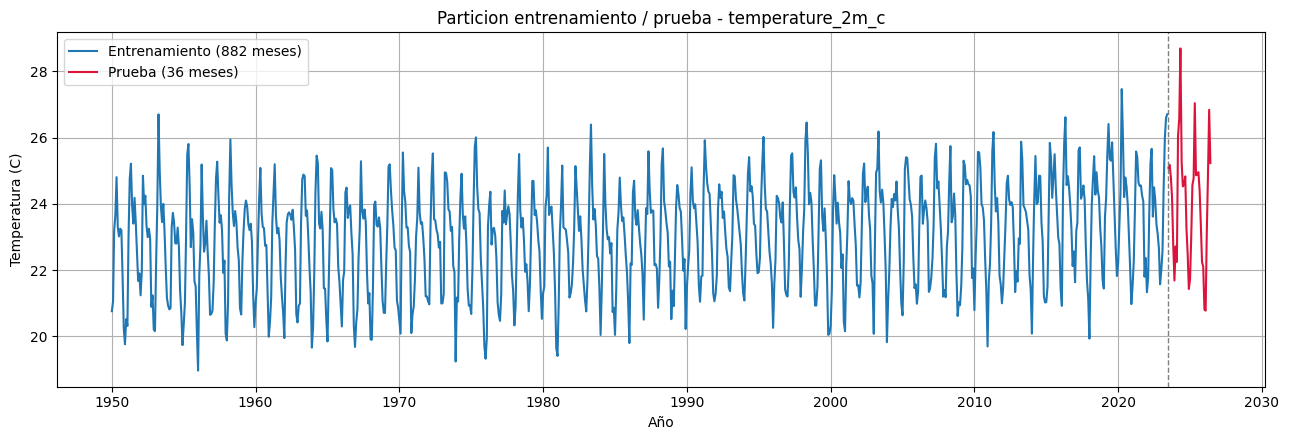

In [10]:
#visualizacion de la particion
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(train.index, train, label=f'Entrenamiento ({len(train)} meses)')
ax.plot(test.index, test, color='crimson', label=f'Prueba ({len(test)} meses)')
ax.axvline(test.index.min(), color='gray', ls='--', lw=1)
ax.set_title("Particion entrenamiento / prueba - temperature_2m_c")
ax.set_xlabel("Año"); ax.set_ylabel("Temperatura (C)")
ax.legend(); plt.tight_layout(); plt.show()

### Respuesta

Pasé la columna a serie de tiempo con frecuencia mensual y dejé los últimos 36 meses para prueba.
El entrenamiento va de enero de 1950 a junio de 2023 (882 meses) y la prueba de julio de 2023 a
junio de 2026 (36 meses).

En series de tiempo la partición se hace respetando el orden, no al azar, porque el modelo se
entrena con el pasado y se prueba con el futuro. Los 36 meses son 3 años completos, suficiente para
ver si capta bien la estacionalidad.


## Ejercicio 3

> Conviértalo en una serie de tiempo y analícela (explique sus razonamientos):
> a) Explore la serie, descompóngala en componentes y analícelos.
> b) Determine si tiene tendencia.
> c) Determine si es estacionaria (recuerde: debe ser estacionaria en media y en varianza).

### 3.a) Descomposición en componentes

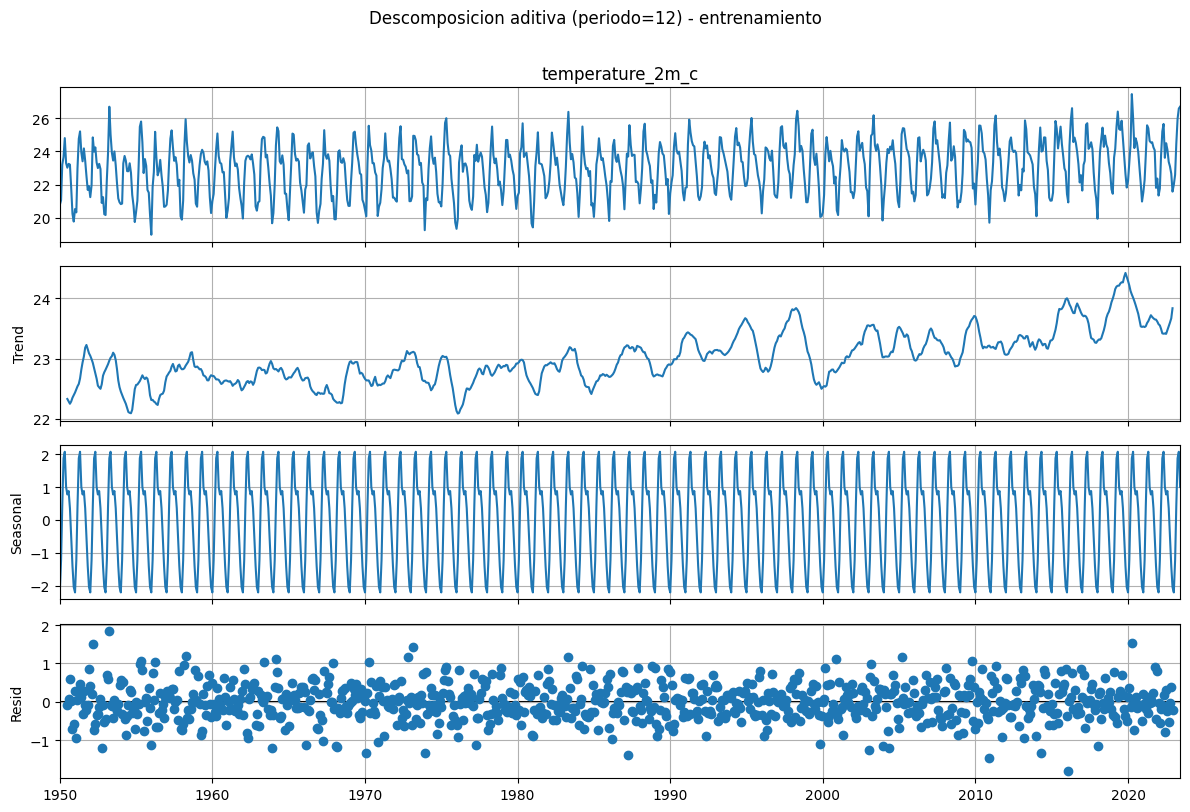

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

#descomposicion aditiva con periodo 12 sobre el entrenamiento
decomp = seasonal_decompose(train, model='additive', period=12)

fig = decomp.plot()
fig.set_size_inches(12, 8)
for a in fig.axes:
    a.grid(True)
fig.suptitle("Descomposicion aditiva (periodo=12) - entrenamiento", y=1.01)
plt.tight_layout(); plt.show()

Amplitud estacional (max-min del patron anual): 4.278 C
Rango de la tendencia: 22.085 -> 24.422 C
Desv. est. del residuo: 0.475 C


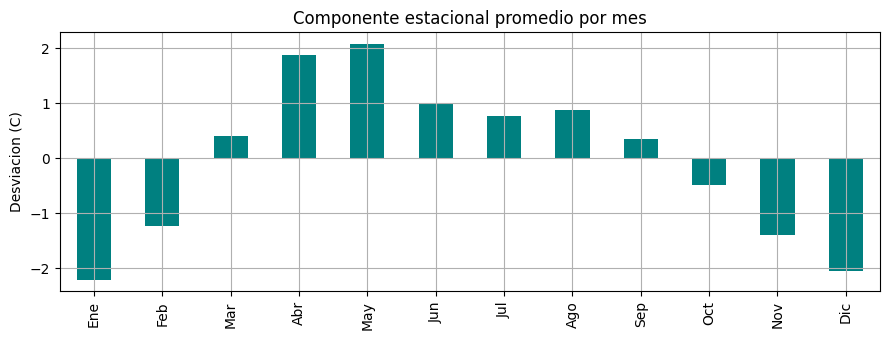

In [12]:
#magnitud de cada componente
print("Amplitud estacional (max-min del patron anual):",
      round(decomp.seasonal.max() - decomp.seasonal.min(), 3), "C")
print("Rango de la tendencia:",
      round(decomp.trend.min(), 3), "->", round(decomp.trend.max(), 3), "C")
print("Desv. est. del residuo:", round(decomp.resid.std(), 3), "C")

#patron estacional promedio por mes
patron_mes = decomp.seasonal.groupby(decomp.seasonal.index.month).mean()
patron_mes.index = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
fig, ax = plt.subplots(figsize=(9,3.5))
patron_mes.plot(kind='bar', ax=ax, color='teal')
ax.set_title("Componente estacional promedio por mes")
ax.set_ylabel("Desviacion (C)"); plt.tight_layout(); plt.show()

### 3.b) ¿Tiene tendencia?

In [13]:
import statsmodels.api as sm

#regresion del tiempo sobre la serie como contraste de tendencia
y = train.values
x = np.arange(len(train))
X = sm.add_constant(x)
ols = sm.OLS(y, X).fit()
pend_dec = ols.params[1] * 120
print(f"Pendiente estimada : {ols.params[1]:.5f} C/mes  ->  {pend_dec:.3f} C/decada")
print(f"p-value pendiente  : {ols.pvalues[1]:.3e}")
print("Conclusion:", "TENDENCIA significativa" if ols.pvalues[1] < 0.05 else "sin tendencia")

Pendiente estimada : 0.00132 C/mes  ->  0.158 C/decada
p-value pendiente  : 7.219e-11
Conclusion: TENDENCIA significativa


### 3.c) ¿Es estacionaria?

In [14]:
from statsmodels.tsa.stattools import adfuller, kpss

def test_adf(serie, nombre=""):
    r = adfuller(serie.dropna(), autolag='AIC')
    print(f"[ADF] {nombre}: estadistico={r[0]:.3f}, p-value={r[1]:.4f}  ->",
          "ESTACIONARIA (rechaza H0)" if r[1] < 0.05 else "NO estacionaria (raiz unitaria)")
    return r[1]

def test_kpss(serie, nombre=""):
    r = kpss(serie.dropna(), regression='c', nlags='auto')
    print(f"[KPSS] {nombre}: estadistico={r[0]:.3f}, p-value={r[1]:.4f}  ->",
          "NO estacionaria (rechaza H0)" if r[1] < 0.05 else "ESTACIONARIA (no rechaza)")
    return r[1]

print("=== Serie original (entrenamiento) ===")
_ = test_adf(train, "original")
_ = test_kpss(train, "original")

=== Serie original (entrenamiento) ===
[ADF] original: estadistico=-4.357, p-value=0.0004  -> ESTACIONARIA (rechaza H0)
[KPSS] original: estadistico=2.419, p-value=0.0100  -> NO estacionaria (rechaza H0)


/var/folders/lc/7cdpz2_528z24s7sg6nmcd900000gn/T/ipykernel_78541/2851721145.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  r = kpss(serie.dropna(), regression='c', nlags='auto')


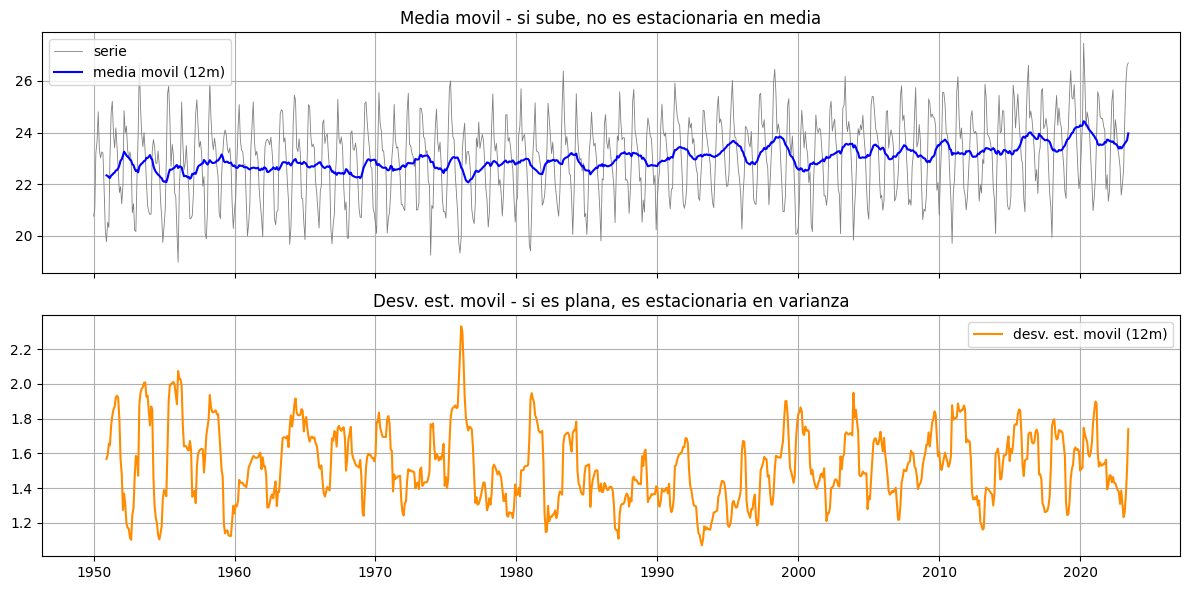

Desv. est. movil: min=1.071, max=2.331, media=1.528


In [15]:
#estacionariedad en varianza con media y desv movil de 12 meses
roll_mean = train.rolling(12).mean()
roll_std  = train.rolling(12).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(train.index, train, lw=0.6, color='gray', label='serie')
ax1.plot(roll_mean.index, roll_mean, color='blue', label='media movil (12m)')
ax1.set_title("Media movil - si sube, no es estacionaria en media"); ax1.legend()
ax2.plot(roll_std.index, roll_std, color='darkorange', label='desv. est. movil (12m)')
ax2.set_title("Desv. est. movil - si es plana, es estacionaria en varianza"); ax2.legend()
plt.tight_layout(); plt.show()

print("Desv. est. movil: min=%.3f, max=%.3f, media=%.3f" %
      (roll_std.min(), roll_std.max(), roll_std.mean()))

### Respuesta

En la parte a descompuse la serie con un modelo aditivo y periodo 12. Usé aditivo porque la
estacionalidad se mantiene más o menos del mismo tamaño con los años. Salen tres partes, una
tendencia que sube despacio de unos 22.1 a 24.4 °C, un patrón estacional anual con amplitud de unos
4.28 °C, y un residuo chico de unos 0.48 °C sin forma clara, así que la descomposición quedó bien.

En la parte b sí hay tendencia. La regresión del tiempo contra la serie da una pendiente de 0.158 °C
por década con un p-value muy chico, así que es clara.

En la parte c la serie no es estacionaria. El ADF dice que sí (p 0.0004) pero el KPSS dice que no
(p 0.01), y cuando se contradicen me quedo con que no lo es, porque la media claramente sube por la
tendencia. La varianza tampoco es del todo constante, la desviación móvil se mueve entre 1.07 y
2.33 °C. Por eso en el siguiente ejercicio la transformo antes de modelarla.
